# Non-local correlators and Green's functions

The same Chebyshev expansion gives non-local correlators/Green's functions
$G_{ij}(\omega)=\langle i|(\omega-H)^{-1}|j\rangle$ between two different sites, without ever
inverting a matrix -- `kpm.dm_ij_energy`, seeded with the pair of sites instead of a single delta
vector. Cross-checked below against the exact Green's function from direct matrix inversion
(`correlator.dm_ij_energy`).

KPM time = 1.941s, exact-inversion time = 9.536s


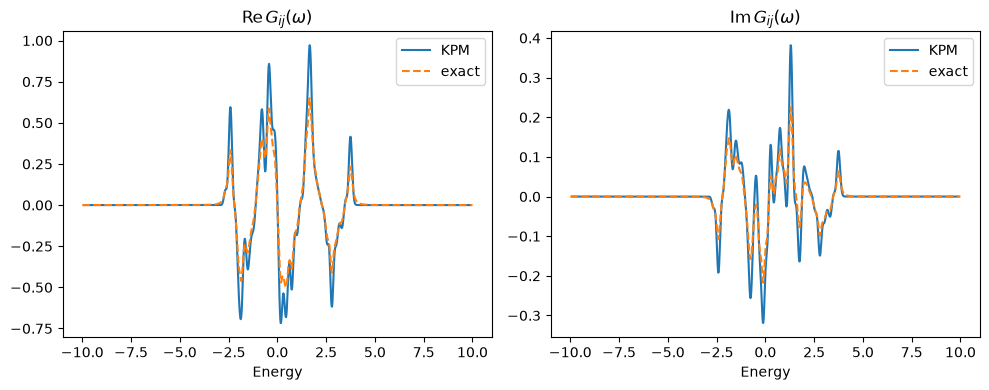

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import correlator, kpm
import time

g = geometry.chain()
g = g.get_supercell(100)
g.dimensionality = 0
h = g.get_hamiltonian()
h.add_rashba(0.5)
h.add_zeeman([0.,1.,0.])
np.random.seed(0)
h.intra += np.diag(np.random.random(h.intra.shape[0])) # weak onsite disorder

i,j = 0,9
t0 = time.time()
(x,y) = kpm.dm_ij_energy(h.intra,npol=200,i=i,j=j,ne=1000)
t1 = time.time()
(x2,y2) = correlator.dm_ij_energy(h.intra,i=i,j=j,delta=0.1,ne=1000)
t2 = time.time()
print(f"KPM time = {t1-t0:.3f}s, exact-inversion time = {t2-t1:.3f}s")

fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].plot(x,y.real,label="KPM") ; axs[0].plot(x2,y2.real,"--",label="exact")
axs[0].set_title("Re$\,G_{ij}(\omega)$") ; axs[0].set_xlabel("Energy") ; axs[0].legend()
axs[1].plot(x,y.imag,label="KPM") ; axs[1].plot(x2,y2.imag,"--",label="exact")
axs[1].set_title("Im$\,G_{ij}(\omega)$") ; axs[1].set_xlabel("Energy") ; axs[1].legend()
plt.tight_layout()
plt.show()